## Navigo Interpolation Benchmarking

Temporal scRNA-seq experiments sample only a discrete set of developmental time points.  Navigo learns a continuous ODE that models the flow of gene expression between time points, enabling interpolation to unseen intermediate stages.

In this tutorial we:
1. Hold out every other time point as a test set
2. Integrate the ODE forward and backward from flanking training times
3. Score predictions with Earth Mover Distance (EMD)
4. Evaluate recovery of cell-type composition and DEG signatures
5. Visualise predictions alongside ground truth in a shared UMAP

In [1]:
import warnings, torch, scanpy as sc
import navigo, navigo.pp, navigo.tl, navigo.pl
from navigo.model import MLPTimeGRN, Navigo
sc.settings.verbosity = 0; warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

Point these three directories at your local copies of the Navigo data, checkpoints, and outputs.

In [2]:
from pathlib import Path
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")

INPUT_DATA      = DATA_DIR / 'interpolation' / 'subtimediff1_hgv.h5ad'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'interpolation' / 'subtimediff1_checkpoint_round10.pth'

output_root = OUTPUT_DIR / 'interpolation_subtimediff1_benchmark'
table_dir   = output_root / '01_tables'
figure_dir  = output_root / '02_figures'
for d in [table_dir, figure_dir]:
    d.mkdir(parents=True, exist_ok=True)

INFER_MODE = 'pred_average'; FLOW_STEPS = 100; ALPHA = 0.5
FOCUS_TIME = 5.5; SEED = 42; MAX_SCORE_CELLS = 512
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
navigo.set_seed(SEED)

## Step 1: Load atlas and prepare time axis

`load_atlas` reads the backed h5ad, parses day labels into a uniform float model-time column (`obs['time']`), and stores gene names and the time↔day mapping in `adata.uns`.

In [3]:
atlas, all_times, model_to_day = navigo.pp.load_atlas(INPUT_DATA)
print(f"Atlas: {atlas.n_obs:,} cells, {len(all_times)} time points")
print(f"Day mapping: {model_to_day}")

Atlas: 84,696 cells, 21 time points
Day mapping: {0.0: 'E8.75', 0.5: 'E9.25', 1.0: 'E9.75', 1.5: 'E10.25', 2.0: 'E10.75', 2.5: 'E11.25', 3.0: 'E11.75', 3.5: 'E12.25', 4.0: 'E12.75', 4.5: 'E13.25', 5.0: 'E13.75', 5.5: 'E14.25', 6.0: 'E14.75', 6.5: 'E15.25', 7.0: 'E15.75', 7.5: 'E16.25', 8.0: 'E16.75', 8.5: 'E17.25', 9.0: 'E17.75', 9.5: 'E18.25', 10.0: 'E18.75'}


## Step 2: Define train / test split

We use every other time point for training and hold out the rest. `interior_test_times` returns only the held-out times that have at least one training time on each side (needed for bidirectional ODE).

In [4]:
train_times = all_times[::2]
test_times  = navigo.tl.interior_test_times(all_times, train_times)
print(f"Train: {len(train_times)} times | Test: {len(test_times)} times")
print(f"Test days: {[model_to_day[t] for t in test_times]}")

Train: 11 times | Test: 10 times
Test days: ['E9.25', 'E10.25', 'E11.25', 'E12.25', 'E13.25', 'E14.25', 'E15.25', 'E16.25', 'E17.25', 'E18.25']


## Step 3: Load trained flow model

`MLPTimeGRN.load_from_checkpoint` infers the architecture (input_dim, hidden sizes) from the saved state dict, so no manual specification is needed.

In [5]:
model = MLPTimeGRN.load_from_checkpoint(CHECKPOINT_PATH, device=DEVICE)
flow  = Navigo(model=model, num_steps=FLOW_STEPS, device=DEVICE)
print(f"Model: input_dim={model.input_dim}, device={DEVICE}")

Model: input_dim=7804, device=cuda


## Step 4: Run ODE interpolation

For each test time *t*, `interpolate_atlas` samples source cells from the previous training time, destination cells from the next, then:
- Integrates the ODE **forward** from source → t
- Integrates the ODE **backward** from destination → t
- Aligns forward predictions to destinations via minimum distance
- Blends: `pred = α·forward + (1−α)·aligned_backward`
- Scores each test time with Earth Mover Distance (EMD)

Returns the predicted cells as an AnnData and the EMD score table.

In [6]:
pred_adata, score_df = navigo.tl.interpolate_atlas(
    flow, atlas,
    train_times=train_times, test_times=test_times,
    infer_mode=INFER_MODE, alpha=ALPHA, max_score_cells=MAX_SCORE_CELLS, seed=SEED,
)
print(f"Predicted {pred_adata.n_obs:,} cells across {pred_adata.obs['day'].nunique()} test times")

Predicted 38,724 cells across 10 test times


In [7]:
score_df.to_csv(table_dir / '01_inference_score_table.csv', index=False)
score_df

,time,day,source_time,dest_time,n_pred_cells,score_sample_cells,emd_prediction,emd_baseline_source,emd_future_stage
0,0.5,E9.25,0.0,1.0,6170,512,5.654253,6.425957,5.873668
1,1.5,E10.25,1.0,2.0,2588,512,4.884382,6.296693,4.749856
2,2.5,E11.25,2.0,3.0,2948,512,5.839323,5.770876,6.777952
3,3.5,E12.25,3.0,4.0,3418,512,6.512604,7.278281,6.448453
4,4.5,E13.25,4.0,5.0,5663,512,5.154602,6.074765,6.010483
5,5.5,E14.25,5.0,6.0,3751,512,5.686710,6.545708,6.019621
6,6.5,E15.25,6.0,7.0,3550,512,5.601690,5.956538,6.475301
7,7.5,E16.25,7.0,8.0,3559,512,6.115338,6.696787,7.096241
8,8.5,E17.25,8.0,9.0,3175,512,9.658496,9.649533,10.177824
9,9.5,E18.25,9.0,10.0,3902,512,5.203116,6.054395,6.054378


## Step 5: Evaluate interpolation quality

At each test time, compare predicted cells to real held-out cells using:
- **DEG overlap** — Wilcoxon rank-sum DEGs between predicted/real vs surrounding cells; Jaccard overlap of top up/down signatures
- **Cell-type JS divergence** — Jensen-Shannon divergence of cell-type frequency distributions
- **Distribution distance** — Wasserstein, MMD, and energy distance in expression space

In [8]:
metrics_df = navigo.tl.evaluate_interpolation(
    pred_adata, atlas,
    test_times=test_times, train_times=train_times, seed=SEED,
)
metrics_df.to_csv(table_dir / '02_benchmark_metrics.csv', index=False)
metrics_df

,time,day,js_divergence,l1_distance,overlap_up,overlap_down,wasserstein_distance,mmd,energy_distance,n_real_cells,n_pred_cells,deg_sample_cells
0,0.5,E9.25,NaN,NaN,0.09,0.26,0.305587,0.031045,0.602640,6170,6170,1024
1,1.5,E10.25,NaN,NaN,0.13,0.13,0.214705,0.010685,0.168979,2588,2588,1024
2,2.5,E11.25,NaN,NaN,0.11,0.15,0.553357,0.091970,1.475166,2948,2948,1024
3,3.5,E12.25,NaN,NaN,0.19,0.18,0.661556,0.078964,1.405153,3418,3418,1024
4,4.5,E13.25,NaN,NaN,0.19,0.12,0.182308,0.009008,0.174982,5663,5663,1024
5,5.5,E14.25,NaN,NaN,0.24,0.12,0.390584,0.029329,0.494467,3751,3751,1024
6,6.5,E15.25,NaN,NaN,0.08,0.11,0.143936,0.003863,0.086398,3550,3550,1024
7,7.5,E16.25,NaN,NaN,0.17,0.30,0.242651,0.005755,0.132731,3559,3559,1024
8,8.5,E17.25,NaN,NaN,0.07,0.11,1.264052,0.165799,3.635675,3175,3175,1024
9,9.5,E18.25,NaN,NaN,0.12,0.22,0.147496,0.003054,0.060068,3902,3902,1024


## Step 6: Build shared UMAP

Project observed start/end cells, ground-truth cells, and Navigo predictions into a joint PCA → neighbor graph → UMAP space to visually assess whether predicted cells overlap with the true held-out population.

In [9]:
umap_adata = navigo.tl.build_interpolation_umap(
    pred_adata, atlas,
    focus_time=FOCUS_TIME, train_times=train_times, test_times=test_times, seed=SEED,
)
print(f"UMAP built for focus day {model_to_day[FOCUS_TIME]}: {umap_adata.n_obs} cells")

UMAP built for focus day E14.25: 12000 cells


## Step 7: Visualize interpolation UMAP

Each panel shows one prediction method. Pale blue = observed start, purple = observed end, red = prediction, dark blue = ground truth.

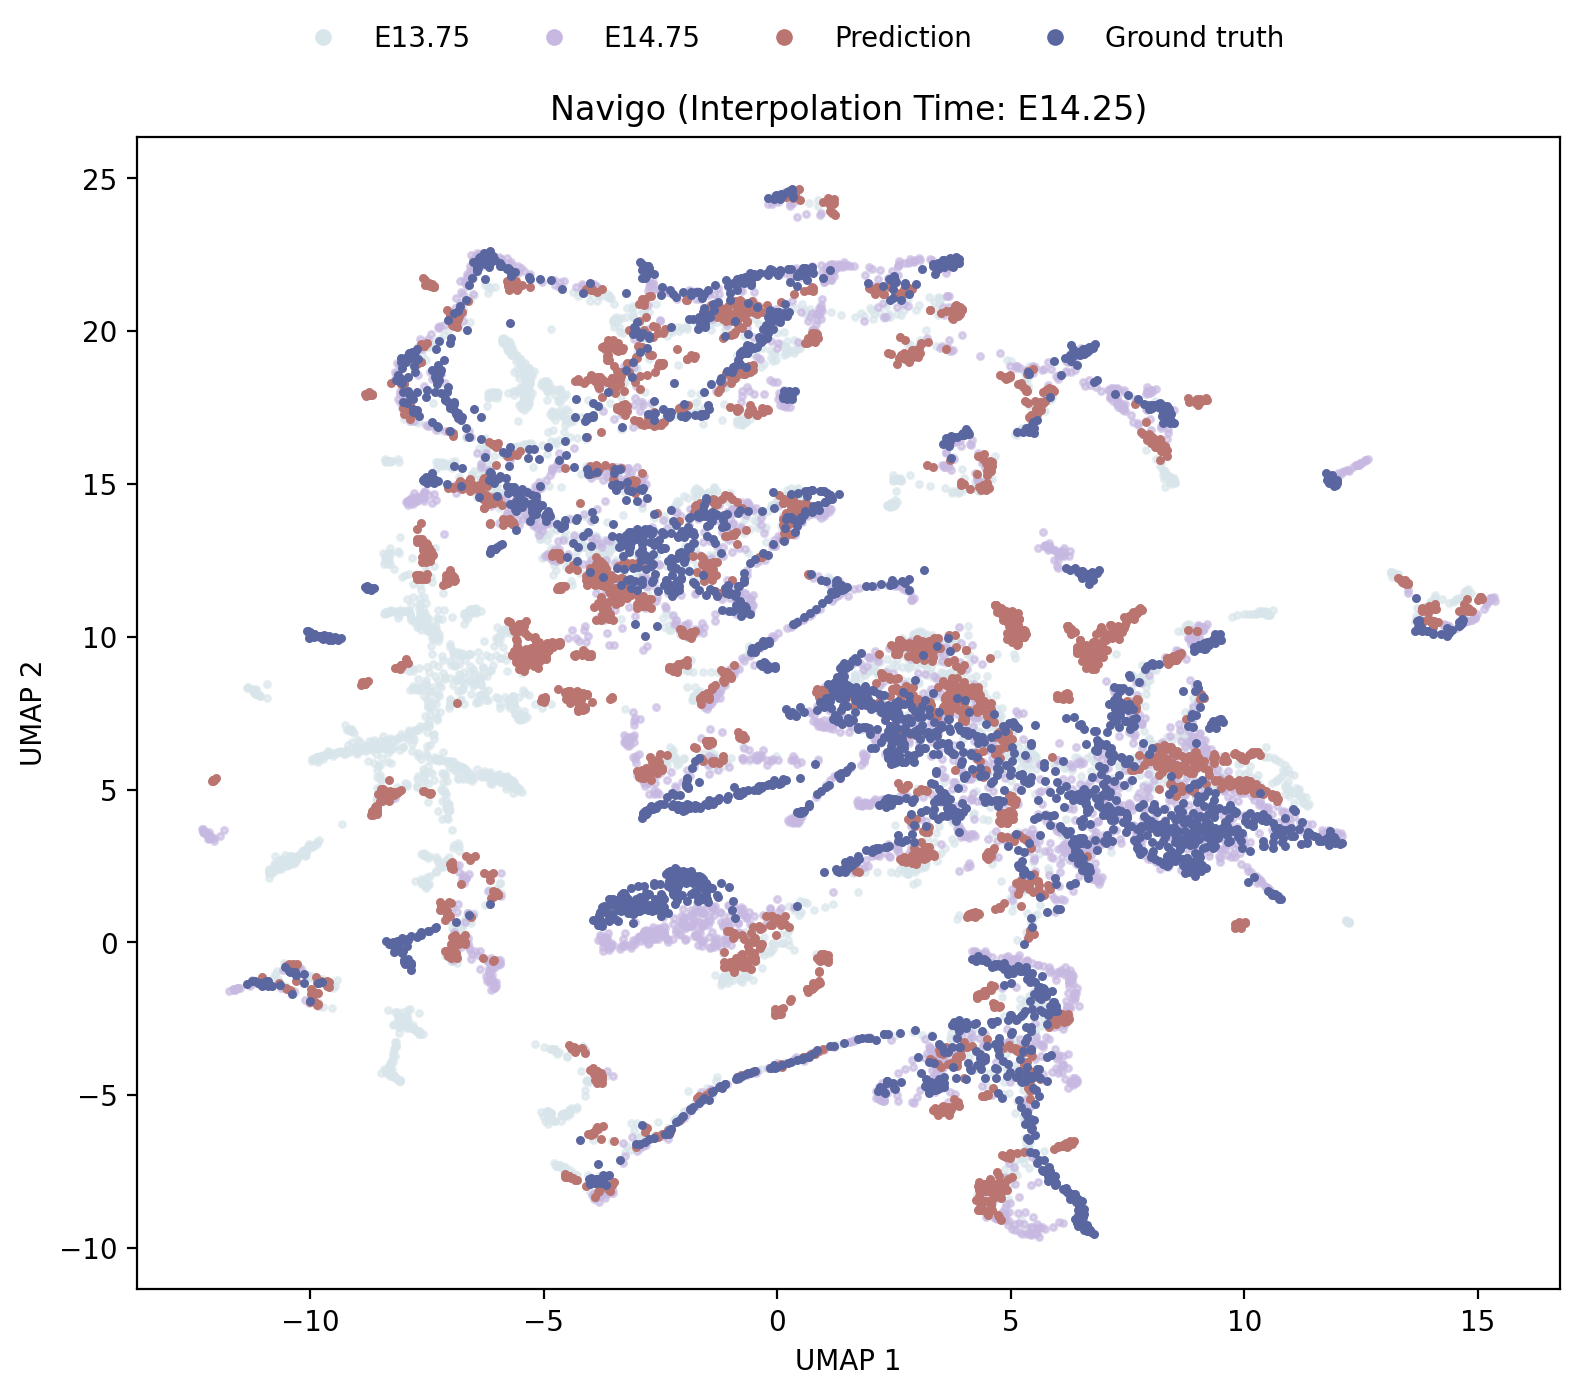

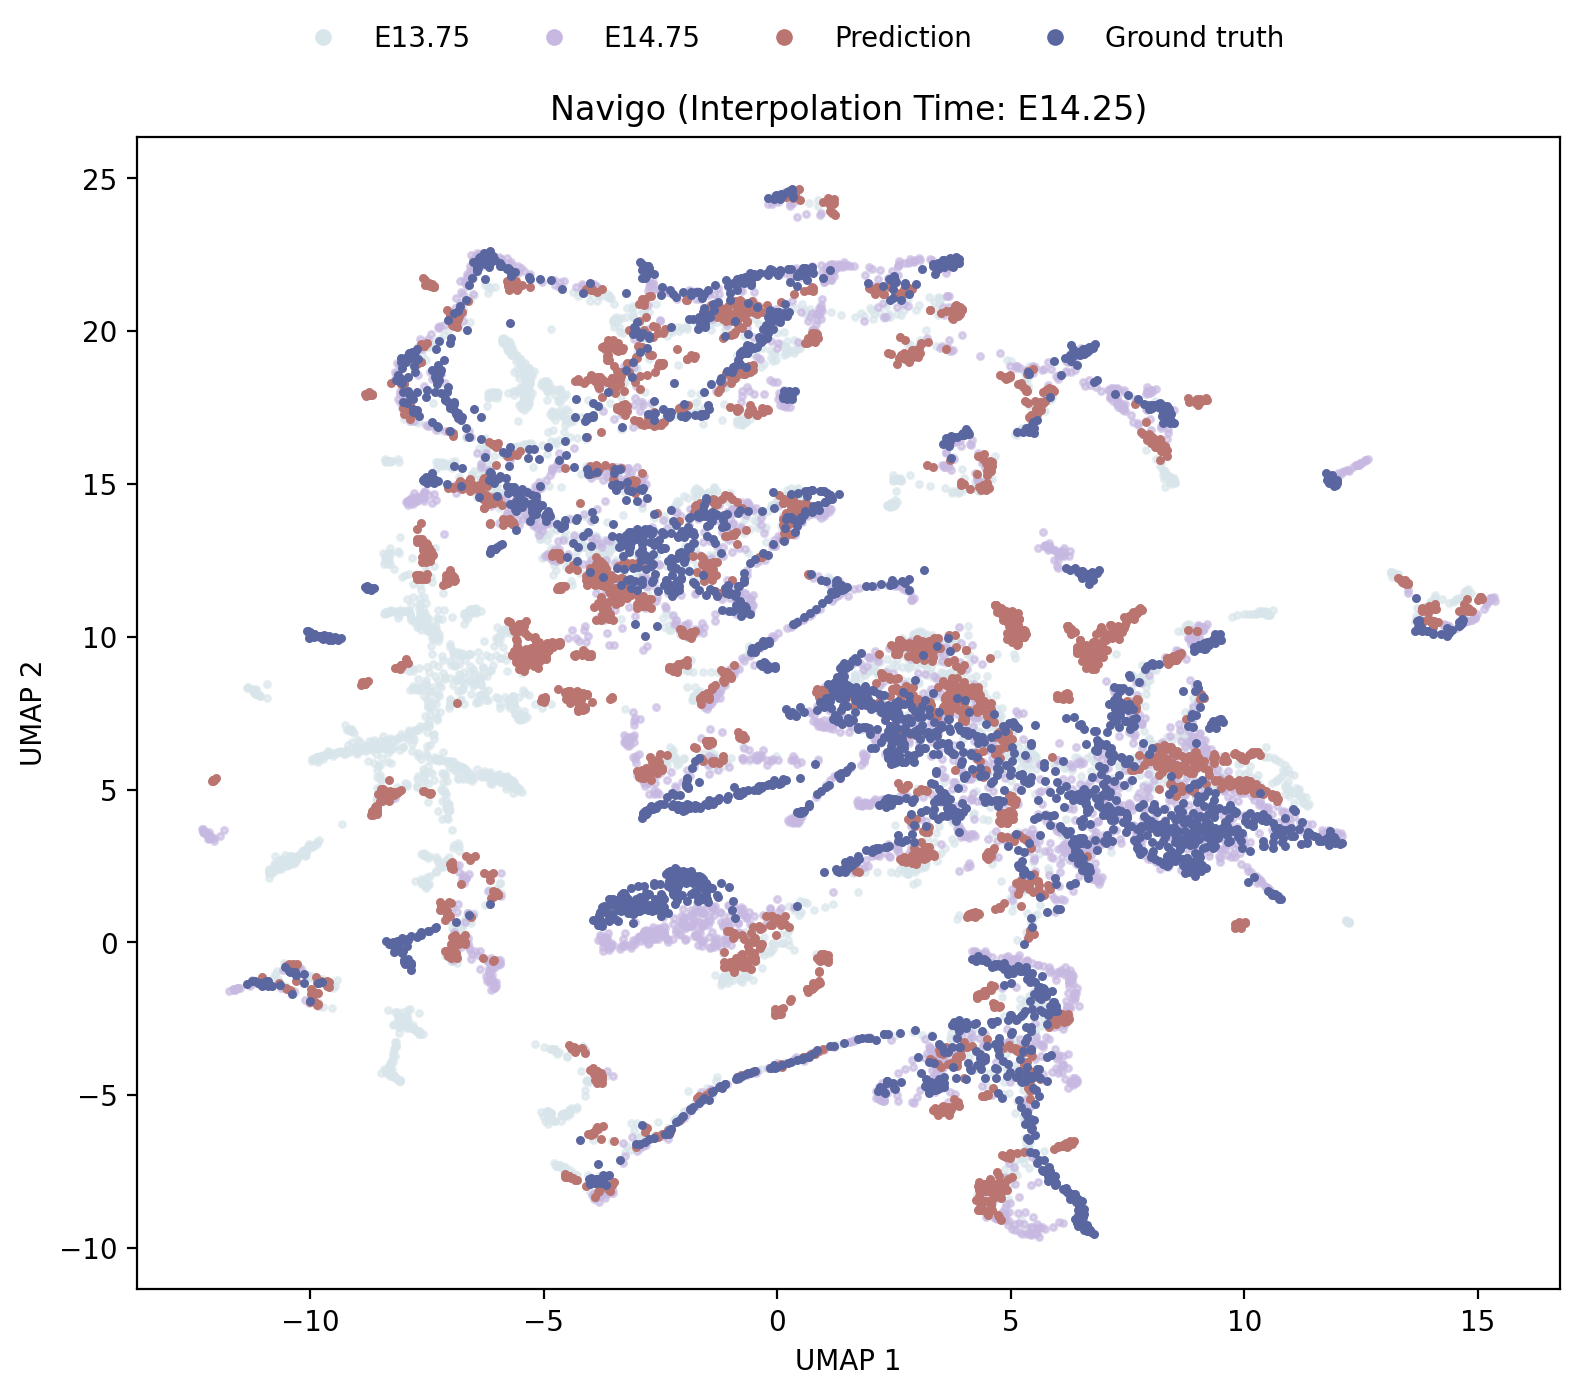

In [10]:
navigo.pl.interpolation_umap(umap_adata, out_path=figure_dir / '01_shared_umap_method_comparison.png')